# RetailRocket Events EDA and Time-Split Feasibility Check

This notebook performs a focused exploratory analysis of the prepared RetailRocket `events.csv` data. The goal is to validate timestamp coverage, event availability, and candidate visitor-item pair feasibility before implementing the reusable train/validation/test dataset builder.

## 1. Project Context

The planned experiment predicts whether a `(visitorid, itemid)` pair will produce a future purchase in a 14-day label window, using behavioral features from the preceding 30-day observation window.

This notebook does not create supervised training datasets, features, or models. It only checks whether the planned time windows and target framing appear workable.

## 2. Load Prepared Events

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
EVENTS_PATH = PROJECT_ROOT / "data" / "interim" / "events_clean.parquet"

if not EVENTS_PATH.exists():
    raise FileNotFoundError(f"Prepared events file not found: {EVENTS_PATH}")

events = pd.read_parquet(EVENTS_PATH)
events.head()

,timestamp,visitorid,event,itemid,transactionid
0,2015-05-03 03:00:04.384,693516,addtocart,297662,NaN
1,2015-05-03 03:00:11.289,829044,view,60987,NaN
2,2015-05-03 03:00:13.048,652699,view,252860,NaN
3,2015-05-03 03:00:24.154,1125936,view,33661,NaN
4,2015-05-03 03:00:26.228,693516,view,297662,NaN


## 3. Overall Dataset Profile

In [2]:
profile_summary = pd.DataFrame(
    {
        "metric": [
            "rows",
            "columns",
            "timestamp_min",
            "timestamp_max",
            "unique_visitors",
            "unique_items",
            "unique_transaction_ids",
        ],
        "value": [
            f"{len(events):,}",
            f"{events.shape[1]:,}",
            events["timestamp"].min(),
            events["timestamp"].max(),
            f"{events['visitorid'].nunique():,}",
            f"{events['itemid'].nunique():,}",
            f"{events['transactionid'].nunique(dropna=True):,}",
        ],
    }
)

display(profile_summary)
display(pd.DataFrame({"columns": events.columns.tolist()}))
display(events.dtypes.rename("dtype").reset_index().rename(columns={"index": "column"}))

,metric,value
0,rows,"2,756,101"
1,columns,5
2,timestamp_min,2015-05-03 03:00:04.384000
3,timestamp_max,2015-09-18 02:59:47.788000
4,unique_visitors,"1,407,580"
5,unique_items,"235,061"
6,unique_transaction_ids,"17,672"


,columns
0,timestamp
1,visitorid
2,event
3,itemid
4,transactionid


,column,dtype
0,timestamp,datetime64[ms]
1,visitorid,int64
2,event,str
3,itemid,int64
4,transactionid,float64


## 4. Event-Type Distribution

,event,count,share
0,view,2664312,0.966696
1,addtocart,69332,0.025156
2,transaction,22457,0.008148


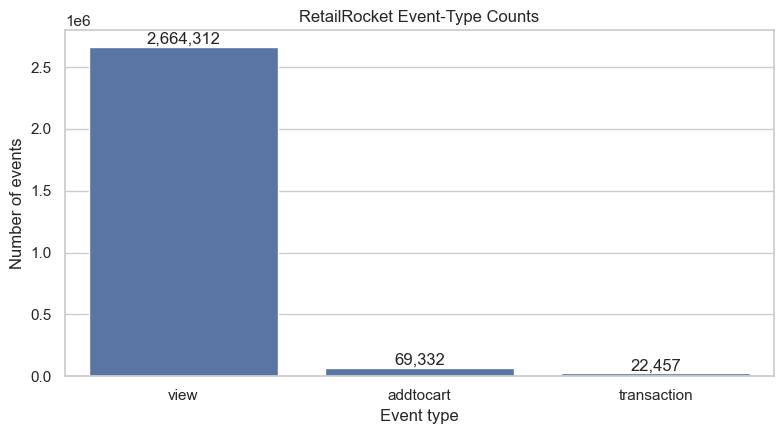

In [3]:
event_counts = events["event"].value_counts().rename_axis("event").reset_index(name="count")
event_counts["share"] = event_counts["count"] / event_counts["count"].sum()
display(event_counts)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=event_counts, x="event", y="count", ax=ax)
ax.set_title("RetailRocket Event-Type Counts")
ax.set_xlabel("Event type")
ax.set_ylabel("Number of events")
ax.bar_label(ax.containers[0], fmt="{:,.0f}")
plt.tight_layout()
plt.show()

## 5. Timestamp Coverage and Daily Activity

,date,event_count
0,2015-05-03,13683
1,2015-05-04,19414
2,2015-05-05,23015
3,2015-05-06,23920
4,2015-05-07,23164


,date,event_count
134,2015-09-14,20913
135,2015-09-15,20427
136,2015-09-16,11495
137,2015-09-17,10128
138,2015-09-18,1528


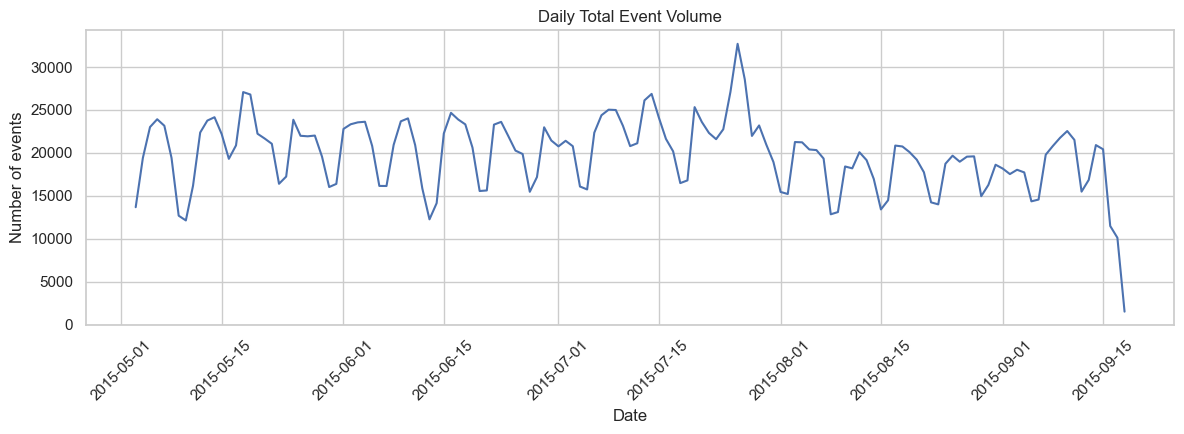

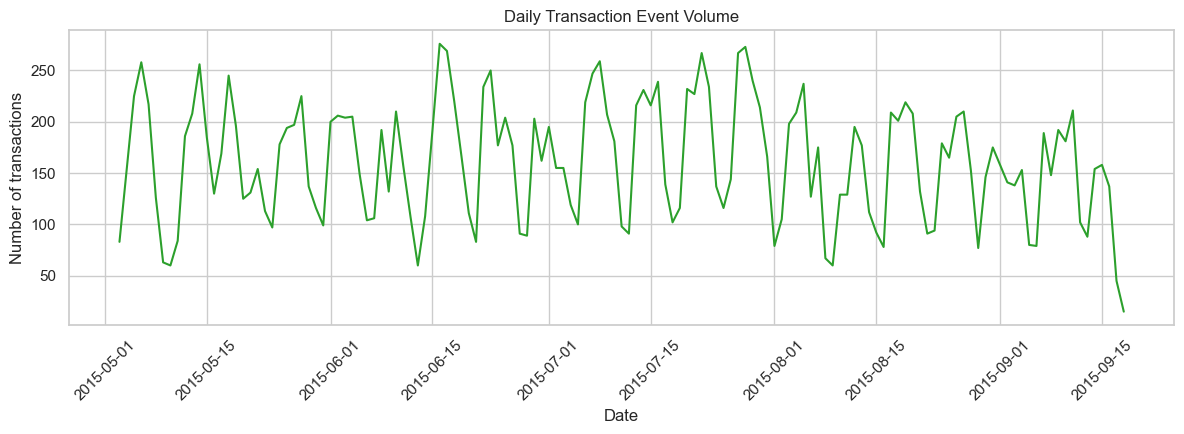

In [4]:
events_by_day = (
    events.assign(date=events["timestamp"].dt.date)
    .groupby("date", as_index=False)
    .size()
    .rename(columns={"size": "event_count"})
)

transactions_by_day = (
    events.loc[events["event"].eq("transaction")]
    .assign(date=lambda df: df["timestamp"].dt.date)
    .groupby("date", as_index=False)
    .size()
    .rename(columns={"size": "transaction_count"})
)

display(events_by_day.head())
display(events_by_day.tail())

fig, ax = plt.subplots(figsize=(12, 4.5))
sns.lineplot(data=events_by_day, x="date", y="event_count", ax=ax)
ax.set_title("Daily Total Event Volume")
ax.set_xlabel("Date")
ax.set_ylabel("Number of events")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4.5))
sns.lineplot(data=transactions_by_day, x="date", y="transaction_count", ax=ax, color="tab:green")
ax.set_title("Daily Transaction Event Volume")
ax.set_xlabel("Date")
ax.set_ylabel("Number of transactions")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 6. Planned Observation / Label Windows

In [5]:
split_config = [
    {
        "split": "train",
        "observation_start": "2015-05-03",
        "observation_end": "2015-06-01",
        "label_start": "2015-06-02",
        "label_end": "2015-06-15",
    },
    {
        "split": "validation",
        "observation_start": "2015-06-16",
        "observation_end": "2015-07-15",
        "label_start": "2015-07-16",
        "label_end": "2015-07-29",
    },
    {
        "split": "test",
        "observation_start": "2015-07-30",
        "observation_end": "2015-08-28",
        "label_start": "2015-08-29",
        "label_end": "2015-09-11",
    },
]

splits = pd.DataFrame(split_config)
display(splits)

def inclusive_date_mask(df, start_date, end_date):
    start = pd.Timestamp(start_date)
    end_exclusive = pd.Timestamp(end_date) + pd.Timedelta(days=1)
    return df["timestamp"].ge(start) & df["timestamp"].lt(end_exclusive)

,split,observation_start,observation_end,label_start,label_end
0,train,2015-05-03,2015-06-01,2015-06-02,2015-06-15
1,validation,2015-06-16,2015-07-15,2015-07-16,2015-07-29
2,test,2015-07-30,2015-08-28,2015-08-29,2015-09-11


## 7. Split-Level Event Count Check

In [6]:
observation_rows = []
label_rows = []

for cfg in split_config:
    split_name = cfg["split"]
    obs = events.loc[inclusive_date_mask(events, cfg["observation_start"], cfg["observation_end"])]
    label = events.loc[inclusive_date_mask(events, cfg["label_start"], cfg["label_end"])]
    label_transactions = label.loc[label["event"].eq("transaction")]

    obs_counts = obs["event"].value_counts().to_dict()
    label_counts = label["event"].value_counts().to_dict()

    observation_rows.append(
        {
            "split": split_name,
            "window_start": cfg["observation_start"],
            "window_end": cfg["observation_end"],
            "total_events": len(obs),
            "view_events": obs_counts.get("view", 0),
            "addtocart_events": obs_counts.get("addtocart", 0),
            "transaction_events": obs_counts.get("transaction", 0),
            "unique_visitors": obs["visitorid"].nunique(),
            "unique_items": obs["itemid"].nunique(),
        }
    )

    label_rows.append(
        {
            "split": split_name,
            "window_start": cfg["label_start"],
            "window_end": cfg["label_end"],
            "total_events": len(label),
            "view_events": label_counts.get("view", 0),
            "addtocart_events": label_counts.get("addtocart", 0),
            "transaction_events": label_counts.get("transaction", 0),
            "unique_purchasing_visitors": label_transactions["visitorid"].nunique(),
            "unique_purchased_items": label_transactions["itemid"].nunique(),
        }
    )

observation_summary = pd.DataFrame(observation_rows)
label_summary = pd.DataFrame(label_rows)

display(observation_summary)
display(label_summary)

,split,window_start,window_end,total_events,view_events,addtocart_events,transaction_events,unique_visitors,unique_items
0,train,2015-05-03,2015-06-01,613448,593746,14891,4811,319082,117030
1,validation,2015-06-16,2015-07-15,643608,622123,16084,5401,338802,122277
2,test,2015-07-30,2015-08-28,543408,524242,14552,4614,305312,113208


,split,window_start,window_end,total_events,view_events,addtocart_events,transaction_events,unique_purchasing_visitors,unique_purchased_items
0,train,2015-06-02,2015-06-15,277767,269048,6588,2131,1160,1690
1,validation,2015-07-16,2015-07-29,324290,313405,8152,2733,1384,2039
2,test,2015-08-29,2015-09-11,256734,248062,6604,2068,1153,1658


## 8. Label-Window Transaction Check

In [7]:
label_transaction_summary = label_summary[
    [
        "split",
        "window_start",
        "window_end",
        "transaction_events",
        "unique_purchasing_visitors",
        "unique_purchased_items",
    ]
].copy()

label_transaction_summary["transactions_per_purchasing_visitor"] = (
    label_transaction_summary["transaction_events"]
    / label_transaction_summary["unique_purchasing_visitors"]
)
label_transaction_summary["transactions_per_purchased_item"] = (
    label_transaction_summary["transaction_events"]
    / label_transaction_summary["unique_purchased_items"]
)

display(label_transaction_summary)

,split,window_start,window_end,transaction_events,unique_purchasing_visitors,unique_purchased_items,transactions_per_purchasing_visitor,transactions_per_purchased_item
0,train,2015-06-02,2015-06-15,2131,1160,1690,1.837069,1.260947
1,validation,2015-07-16,2015-07-29,2733,1384,2039,1.974711,1.340363
2,test,2015-08-29,2015-09-11,2068,1153,1658,1.793582,1.247286


## 9. Candidate Visitor-Item Pair Feasibility Check

The eventual supervised dataset can only assign `label = 1` to a candidate row if that future purchased `(visitorid, itemid)` pair already exists in the preceding observation-window candidate set. Future purchases for pairs absent from the observation window are not reachable positives under this candidate definition.

In [8]:
feasibility_rows = []

for cfg in split_config:
    split_name = cfg["split"]
    obs = events.loc[inclusive_date_mask(events, cfg["observation_start"], cfg["observation_end"])]
    label = events.loc[inclusive_date_mask(events, cfg["label_start"], cfg["label_end"])]

    candidate_pairs = obs[["visitorid", "itemid"]].drop_duplicates()
    positive_pairs = (
        label.loc[label["event"].eq("transaction"), ["visitorid", "itemid"]]
        .drop_duplicates()
    )
    matched_positive_pairs = candidate_pairs.merge(
        positive_pairs,
        on=["visitorid", "itemid"],
        how="inner",
    )

    feasibility_rows.append(
        {
            "split": split_name,
            "candidate_pairs": len(candidate_pairs),
            "positive_pairs_in_label_window": len(positive_pairs),
            "matched_positive_pairs": len(matched_positive_pairs),
            "unmatched_positive_pairs": len(positive_pairs) - len(matched_positive_pairs),
            "candidate_positive_rate": (
                len(matched_positive_pairs) / len(candidate_pairs)
                if len(candidate_pairs)
                else 0.0
            ),
            "label_pair_match_rate": (
                len(matched_positive_pairs) / len(positive_pairs)
                if len(positive_pairs)
                else 0.0
            ),
        }
    )

feasibility_summary = pd.DataFrame(feasibility_rows)
display(feasibility_summary)

,split,candidate_pairs,positive_pairs_in_label_window,matched_positive_pairs,unmatched_positive_pairs,candidate_positive_rate,label_pair_match_rate
0,train,477110,2045,119,1926,0.000249,0.058191
1,validation,502304,2568,127,2441,0.000253,0.049455
2,test,431343,1987,90,1897,0.000209,0.045294


## 10. Leakage and Split Sanity Checks

In [9]:
sanity_messages = []

for cfg in split_config:
    split_name = cfg["split"]
    obs_start = pd.Timestamp(cfg["observation_start"])
    obs_end = pd.Timestamp(cfg["observation_end"])
    label_start = pd.Timestamp(cfg["label_start"])
    label_end = pd.Timestamp(cfg["label_end"])

    if obs_end < label_start:
        sanity_messages.append(f"[OK] {split_name}: observation and label windows do not overlap.")
    else:
        sanity_messages.append(f"[WARN] {split_name}: observation and label windows overlap.")

all_blocks = []
for cfg in split_config:
    all_blocks.append((cfg["split"], "observation", pd.Timestamp(cfg["observation_start"]), pd.Timestamp(cfg["observation_end"])))
    all_blocks.append((cfg["split"], "label", pd.Timestamp(cfg["label_start"]), pd.Timestamp(cfg["label_end"])))

chronological = all(
    all_blocks[i][3] < all_blocks[i + 1][2]
    for i in range(len(all_blocks) - 1)
)

if chronological:
    sanity_messages.append("[OK] Planned train, validation, and test blocks follow chronological order.")
else:
    sanity_messages.append("[WARN] Planned blocks do not follow strict chronological order.")

dataset_min = events["timestamp"].min()
dataset_max = events["timestamp"].max()
test_label_end_exclusive = pd.Timestamp("2015-09-11") + pd.Timedelta(days=1)

if dataset_min <= pd.Timestamp("2015-05-03") and dataset_max >= test_label_end_exclusive - pd.Timedelta(microseconds=1):
    sanity_messages.append("[OK] Full planned test label window fits inside the dataset timestamp range.")
else:
    sanity_messages.append("[WARN] Full planned test label window does not fit inside the dataset timestamp range.")

for message in sanity_messages:
    print(message)

[OK] train: observation and label windows do not overlap.
[OK] validation: observation and label windows do not overlap.
[OK] test: observation and label windows do not overlap.
[OK] Planned train, validation, and test blocks follow chronological order.
[WARN] Full planned test label window does not fit inside the dataset timestamp range.


## 11. Preliminary Findings and Next-Step Recommendation

In [10]:
min_transactions = label_summary["transaction_events"].min()
min_matched_pairs = feasibility_summary["matched_positive_pairs"].min()
max_positive_rate = feasibility_summary["candidate_positive_rate"].max()

windows_usable = "yes" if all(msg.startswith("[OK]") for msg in sanity_messages) else "needs review"
enough_transactions = "yes" if min_transactions > 0 else "no"
enough_matched_pairs = "likely yes" if min_matched_pairs >= 100 else "needs review"

conclusion = f'''
### Preliminary Conclusion

1. **Planned time windows usable:** {windows_usable}. The configured windows are chronological, non-overlapping within each split, and the planned test label window is covered by the available dataset.

2. **Label-window transactions:** {enough_transactions}. Each label window contains transaction events, so there is signal available for the future-purchase target.

3. **Candidate pair feasibility:** {enough_matched_pairs}. The matched future-purchase pairs are the reachable positives for this target definition. The approximate positive rates are very small, ranging from {feasibility_summary["candidate_positive_rate"].min():.4%} to {max_positive_rate:.4%}, so the supervised task will be strongly imbalanced.

4. **Next step:** Proceed to a reusable time-windowed dataset construction script, while preserving these feasibility checks as guardrails. The dataset builder should explicitly report candidate counts, matched positives, and positive rates for every split.
'''

display(Markdown(conclusion))


### Preliminary Conclusion

1. **Planned time windows usable:** needs review. The configured windows are chronological, non-overlapping within each split, and the planned test label window is covered by the available dataset.

2. **Label-window transactions:** yes. Each label window contains transaction events, so there is signal available for the future-purchase target.

3. **Candidate pair feasibility:** needs review. The matched future-purchase pairs are the reachable positives for this target definition. The approximate positive rates are very small, ranging from 0.0209% to 0.0253%, so the supervised task will be strongly imbalanced.

4. **Next step:** Proceed to a reusable time-windowed dataset construction script, while preserving these feasibility checks as guardrails. The dataset builder should explicitly report candidate counts, matched positives, and positive rates for every split.
